# 06 — Further Analysis: Systems-Level Consensus, Lateralization & Effect Size

**Purpose:** Post-hoc analyses of interpretability artifacts produced by `05_run_interpretability_ad.ipynb`.  
This notebook is **analysis-only** — it does NOT retrain models.

| § | Content | Key outputs |
|---|---------|-------------|
| §1 | Configuration | Single cell for all user-editable knobs |
| §2 | Imports & style | Publication-ready matplotlib defaults |
| §3 | Artifact discovery | `run_manifest.json`, provenance table |
| §4 | Load interpretability results | `df_full` — canonical edge saliency frame |
| §5 | Consensus stability & heatmaps | systems signature, biomarker map |
| §6 | Lateralization analysis | right-hemisphere dominance |
| §7 | Effect size & Saliency vs d | Cohen's d per edge, quadrant scatter |
| §8 | Glass brain & chord diagrams | connectome + network/ROI chords |
| §IT | Information theory | fold-level entropy, MI analysis |
| §F | Outputs index | `outputs_index.csv` |

**Inputs required:**
- `results/vae_3channels_beta65_pro/` (training artifacts from `run_vae_clf_ad_inference.py`)
- `results/vae_3channels_beta65_pro/fold_k/interpretability_*` (from `05_run_interpretability_ad.ipynb`)
- `data/SubjectsData_AAL3_procesado2.csv` (metadata)
- `data/**/GLOBAL_TENSOR*.npz` (optional: needed for Cohen's d)

**How to run:** `Kernel → Restart & Run All`


In [1]:
# ─── §1 — Configuration (ONLY user-editable cell) ──────────────────────────
from pathlib import Path
import os

# ── Project root (auto-detected) ────────────────────────────────────────────
_PROJECT_ROOT = Path(__file__).resolve().parent.parent if "__file__" in dir() else Path.cwd().parent
if not (_PROJECT_ROOT / "src").is_dir():
    _PROJECT_ROOT = Path.cwd()
    while _PROJECT_ROOT != _PROJECT_ROOT.parent:
        if (_PROJECT_ROOT / "src").is_dir() and (_PROJECT_ROOT / "pyproject.toml").is_file():
            break
        _PROJECT_ROOT = _PROJECT_ROOT.parent

# ── Main knobs ───────────────────────────────────────────────────────────────
PREFERRED_RUN   = "vae_3channels_beta65_pro"
RESULTS_DIR     = _PROJECT_ROOT / "results" / PREFERRED_RUN
TARGET_CLF      = "logreg"

# Paths (most resolved automatically in §3; set to None for auto-detection)
METADATA_PATH: Path | None     = _PROJECT_ROOT / "data" / "SubjectsData_AAL3_procesado2.csv"
GLOBAL_TENSOR_PATH: Path | None = None   # auto-discovered under data/

# Output structure
OUTPUT_DIR = RESULTS_DIR / "further_analysis_paper_output"
FIG_DIR    = OUTPUT_DIR / "Figures"
TBL_DIR    = OUTPUT_DIR / "Tables"
LOG_DIR    = OUTPUT_DIR / "logs"
for _d in (OUTPUT_DIR, FIG_DIR, TBL_DIR, LOG_DIR):
    _d.mkdir(parents=True, exist_ok=True)

# Reproducibility
SEED_GLOBAL   = 42
SHOW_FIGURES  = True

# Consensus knobs (match 05 notebook defaults)
SUFFIX             = "_integrated_gradients_top50"
TOP_K_STABILITY    = 250
CONS_PI            = 0.60
CONS_TAU           = 0.60
SALIENCY_METHOD    = "integrated_gradients"
TOPK_LATENTS       = 50

# Lateralization
LATERALIZATION_KS  = [50, 100, 200]

# Effect size
EFFECT_CHANNEL_AGG = "mean_channels"   # "mean_channels" | "per_channel"
USE_NORM_FOR_D     = False              # True → z-scored tensor; False → raw

# Atlas (optional — for glass brain only)
AAL3_DIR: Path | None = None   # e.g. _PROJECT_ROOT / "data" / "aal3_atlas"

# Chord diagrams
CHORD_TOP_K_PAIRS  = 24
CHORD_TOP_K_ROI    = 24

# Smoke test: set to a fold number (e.g. 1) to run only one fold
SMOKE_FOLD: int | None = None

# ── Aliases for downstream cells ─────────────────────────────────────────────
CLF       = TARGET_CLF
SEED      = SEED_GLOBAL
RUN_DIR   = RESULTS_DIR

print(f"[§1] PROJECT_ROOT : {_PROJECT_ROOT}")
print(f"[§1] RESULTS_DIR  : {RESULTS_DIR}")
print(f"[§1] OUTPUT_DIR   : {OUTPUT_DIR}")
print(f"[§1] TARGET_CLF   : {TARGET_CLF}")


[§1] PROJECT_ROOT : /home/diego/proyectos/vae_AD
[§1] RESULTS_DIR  : /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro
[§1] OUTPUT_DIR   : /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/further_analysis_paper_output
[§1] TARGET_CLF   : logreg


In [2]:
# ─── §2 — Imports & style ───────────────────────────────────────────────────
import os, sys, re, json, random, warnings, logging, itertools, hashlib
from pathlib import Path
from datetime import datetime, timezone
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from scipy import stats
from scipy.stats import spearmanr, ttest_1samp
from IPython.display import display

# Suppress noisy warnings
warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("fontTools").setLevel(logging.WARNING)

# Reproducibility
random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)
np.random.seed(SEED)

try:
    import torch
    torch.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
except ImportError:
    pass

# ── Publication style ────────────────────────────────────────────────────────
def set_nature_style():
    """Nature-ready matplotlib defaults."""
    sns.set_theme(style="white", context="paper")
    mpl.rcParams.update({
        "pdf.fonttype": 42, "ps.fonttype": 42, "svg.fonttype": "none",
        "font.family": "sans-serif",
        "font.sans-serif": ["Arial", "DejaVu Sans"],
        "font.size": 9, "axes.titlesize": 10, "axes.labelsize": 9,
        "xtick.labelsize": 8, "ytick.labelsize": 8, "legend.fontsize": 8,
        "axes.spines.top": False, "axes.spines.right": False,
        "axes.linewidth": 0.8, "xtick.major.width": 0.8, "ytick.major.width": 0.8,
        "xtick.direction": "out", "ytick.direction": "out",
        "figure.dpi": 150, "savefig.dpi": 400, "savefig.pad_inches": 0.02,
    })

set_nature_style()

def savefig_nature(fig, path_no_ext, dpi_png=600, transparent_png=False):
    """Save figure as PDF + PNG + SVG (Nature-ready)."""
    p = Path(path_no_ext)
    p.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(p.with_suffix(".pdf"), bbox_inches="tight",
                metadata={"Creator": "Matplotlib", "Title": p.name,
                           "CreationDate": datetime.now()})
    fig.savefig(p.with_suffix(".png"), dpi=dpi_png, transparent=transparent_png,
                bbox_inches="tight")
    fig.savefig(p.with_suffix(".svg"), bbox_inches="tight")

# Verify betavae_xai is importable
try:
    import betavae_xai
    print(f"[§2] betavae_xai: {betavae_xai.__file__}")
except ImportError:
    print("[§2] betavae_xai not in PYTHONPATH; standalone mode")

print("[§2] Setup OK.")


[§2] betavae_xai: /home/diego/proyectos/vae_AD/src/betavae_xai/__init__.py
[§2] Setup OK.


In [3]:
# ─── §3 — Artifact discovery (single source of truth) ───────────────────────

# §3a — Validate RESULTS_DIR + load run_config.json
if not RESULTS_DIR.exists():
    raise FileNotFoundError(f"[§3] RESULTS_DIR not found: {RESULTS_DIR}")

_cfg_path = RESULTS_DIR / "run_config.json"
if not _cfg_path.exists():
    raise FileNotFoundError(f"[§3] run_config.json not found in {RESULTS_DIR}")
run_cfg = json.loads(_cfg_path.read_text("utf-8"))
run_args = run_cfg.get("args", {})

# Infer RUN_TAG from summary_metrics filename
_summary_glob = list(RESULTS_DIR.glob("summary_metrics_MULTI_*.txt"))
if _summary_glob:
    _m = re.search(r"summary_metrics_MULTI_(.+)", _summary_glob[0].stem)
    RUN_TAG = _m.group(1) if _m else _summary_glob[0].stem
else:
    RUN_TAG = "unknown"
print(f"[§3] RUN_TAG : {RUN_TAG[:80]}")

# §3b — Resolve tensor / metadata
def _resolve(cfg_key, fallback):
    raw = run_args.get(cfg_key)
    if raw:
        p = Path(raw)
        return p if p.is_absolute() else (RESULTS_DIR / p).resolve()
    return fallback

if GLOBAL_TENSOR_PATH is None:
    # Auto-discover under data/
    _tensor_cands = sorted((_PROJECT_ROOT / "data").rglob("GLOBAL_TENSOR*.npz"))
    if _tensor_cands:
        GLOBAL_TENSOR_PATH = _tensor_cands[0]
    else:
        print("[§3][WARN] No GLOBAL_TENSOR*.npz found under data/. Cohen's d section will be skipped.")

if METADATA_PATH is None:
    METADATA_PATH = _PROJECT_ROOT / "data" / "SubjectsData_AAL3_procesado2.csv"

ROI_INFO_PATH = RESULTS_DIR / "roi_info_from_tensor.csv"

for _lbl, _p in [("GLOBAL_TENSOR_PATH", GLOBAL_TENSOR_PATH),
                  ("METADATA_PATH", METADATA_PATH),
                  ("ROI_INFO_PATH", ROI_INFO_PATH)]:
    _st = "OK" if _p is not None and _p.exists() else "MISSING"
    print(f"  [{_st}] {_lbl}: {_p}")

# §3c — VAE / classifier params from run_config
CHANNELS_TO_USE = list(map(int, run_args.get("channels_to_use", [1, 0, 2])))
N_FOLDS_CFG     = int(run_args.get("outer_folds", 5))

# §3d — Detect valid folds
_fold_candidates = sorted(
    int(p.name.split("_")[1])
    for p in RESULTS_DIR.glob("fold_*")
    if p.is_dir() and p.name.split("_")[-1].isdigit()
)
FOLDS = [
    k for k in _fold_candidates
    if (RESULTS_DIR / f"fold_{k}" / f"vae_model_fold_{k}.pt").exists()
       and (RESULTS_DIR / f"fold_{k}" / "test_subjects_fold.csv").exists()
]
if SMOKE_FOLD is not None:
    FOLDS = [f for f in FOLDS if f == SMOKE_FOLD]
N_FOLDS = len(FOLDS)
if not FOLDS:
    raise RuntimeError(f"[§3] No valid folds in {RESULTS_DIR}")
print(f"[§3] FOLDS: {FOLDS}  |  CHANNELS: {CHANNELS_TO_USE}")

# §3e — ROI info (canonical ROI ordering + network labels)
if not ROI_INFO_PATH.exists():
    raise FileNotFoundError(f"[§3] roi_info_from_tensor.csv missing: {ROI_INFO_PATH}")

roi_info_df = pd.read_csv(ROI_INFO_PATH)
# Expected cols: roi_name_in_tensor, network_label_in_tensor
roi_info_df.columns = [c.strip() for c in roi_info_df.columns]
roi_info_df["Index_131"] = range(len(roi_info_df))
N_ROIS = len(roi_info_df)

roi_order = roi_info_df["roi_name_in_tensor"].tolist()
roi2net = dict(zip(roi_info_df["roi_name_in_tensor"], roi_info_df["network_label_in_tensor"]))
roi2idx = {r: i for i, r in enumerate(roi_order)}

print(f"[§3] N_ROIS: {N_ROIS} | Networks: {roi_info_df['network_label_in_tensor'].nunique()}")

# §3f — Load metadata
meta = pd.read_csv(METADATA_PATH)
meta["SubjectID"] = meta["SubjectID"].astype(str).str.strip()
if "Sex" in meta.columns:
    meta["Sex"] = meta["Sex"].replace({0: "M", 1: "F", "m": "M", "f": "F"}).astype(str).str.upper()
if "Age" in meta.columns:
    meta["Age"] = pd.to_numeric(meta["Age"], errors="coerce")

# §3g — Build fold test/train indices aligned to tensor (new pipeline style)
fold_indices = {}
for f in FOLDS:
    fd = RESULTS_DIR / f"fold_{f}"
    # test_subjects_fold.csv has: SubjectID, tensor_idx, ResearchGroup_Mapped
    test_subj = pd.read_csv(fd / "test_subjects_fold.csv")
    test_subj["SubjectID"] = test_subj["SubjectID"].astype(str).str.strip()
    test_tensor_idx = test_subj["tensor_idx"].to_numpy(dtype=int)
    test_labels = test_subj["ResearchGroup_Mapped"].to_numpy()
    # Also load train_dev if available
    train_path = fd / "train_dev_subjects_fold.csv"
    if train_path.exists():
        train_subj = pd.read_csv(train_path)
        train_tensor_idx = train_subj["tensor_idx"].to_numpy(dtype=int)
    else:
        train_tensor_idx = None
    fold_indices[f] = {
        "test_tensor_idx": test_tensor_idx,
        "test_labels": test_labels,
        "train_tensor_idx": train_tensor_idx,
    }
print(f"[§3] fold_indices built for {len(fold_indices)} folds.")

# §3h — Channel catalog
CHANNEL_CATALOG = {
    0: "Pearson_OMST_GCE_Signed_Weighted",
    1: "Pearson_Full_FisherZ_Signed",
    2: "MI_kNN_Symmetric",
    3: "dFC_AbsDiffMean",
    4: "dFC_StdDev",
    5: "DistanceCorr",
    6: "Granger_F_lag1",
}
sel_names = [CHANNEL_CATALOG.get(c, f"Ch{c}") for c in CHANNELS_TO_USE]
print(f"[§3] Channels: {CHANNELS_TO_USE} → {sel_names}")

# §3i — Manifest
def _sha256_short(p):
    try: return hashlib.sha256(p.read_bytes()).hexdigest()[:12]
    except: return "N/A"

_manifest = {
    "created_utc": datetime.now(timezone.utc).isoformat(),
    "results_dir": str(RESULTS_DIR),
    "output_dir": str(OUTPUT_DIR),
    "run_tag": RUN_TAG,
    "target_clf": TARGET_CLF,
    "folds": FOLDS,
    "channels_to_use": CHANNELS_TO_USE,
    "n_rois": N_ROIS,
    "suffix": SUFFIX,
    "top_k_stability": TOP_K_STABILITY,
    "cons_pi": CONS_PI,
    "cons_tau": CONS_TAU,
}
_mf_path = OUTPUT_DIR / "run_manifest.json"
_mf_path.write_text(json.dumps(_manifest, indent=2), encoding="utf-8")
print(f"\n[§3] Manifest → {_mf_path}")


[§3] RUN_TAG : svm_vaeconvtranspose4l_ld256_beta6.5_normzscore_offdiag_ch3sel_intFCquarter_drop
  [OK] GLOBAL_TENSOR_PATH: /home/diego/proyectos/vae_AD/data/AAL3_dynamicROIs_fmri_tensor_NeuroEnhanced_v6.5.17_AAL3_131ROIs_OMST_GCE_Signed_GrangerLag1_ChNorm_ROIreorderedYeo17_ParallelTuned/GLOBAL_TENSOR_from_AAL3_dynamicROIs_fmri_tensor_NeuroEnhanced_v6.5.17_AAL3_131ROIs_OMST_GCE_Signed_GrangerLag1_ChNorm_ROIreorderedYeo17_ParallelTuned.npz
  [OK] METADATA_PATH: /home/diego/proyectos/vae_AD/data/SubjectsData_AAL3_procesado2.csv
  [OK] ROI_INFO_PATH: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/roi_info_from_tensor.csv
[§3] FOLDS: [1, 2, 3, 4, 5]  |  CHANNELS: [1, 0, 2]
[§3] N_ROIS: 131 | Networks: 16
[§3] fold_indices built for 5 folds.
[§3] Channels: [1, 0, 2] → ['Pearson_Full_FisherZ_Signed', 'Pearson_OMST_GCE_Signed_Weighted', 'MI_kNN_Symmetric']

[§3] Manifest → /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/further_analysis_paper_output/run_manifest.js

In [4]:
# ─── §4 — Load interpretability results into df_full ────────────────────────
#
# Canonical columns:
#   fold, connection_id, idx_i, idx_j, Saliency_Signed, Saliency_Abs, Rank,
#   src_AAL3_Name, dst_AAL3_Name, src_Refined_Network, dst_Refined_Network,
#   src_Yeo17_Network, dst_Yeo17_Network

all_folds_dfs = []
missing_folds = []

for f in FOLDS:
    rpath = (
        RESULTS_DIR / f"fold_{f}" / f"interpretability_{CLF}"
        / f"ranking_conexiones_ANOTADO{SUFFIX}.csv"
    )
    if not rpath.exists():
        missing_folds.append(f)
        continue
    df_i = pd.read_csv(rpath)
    # Canonical connection_id (undirected, sorted tuple of ROI names)
    df_i["connection_id"] = [
        tuple(sorted((str(a), str(b))))
        for a, b in zip(df_i["src_AAL3_Name"], df_i["dst_AAL3_Name"])
    ]
    df_i["fold"] = f
    all_folds_dfs.append(df_i)

if not all_folds_dfs:
    _msg = (
        "No ranking_conexiones_ANOTADO*.csv found under any fold.\n"
        "You must run 05_run_interpretability_ad.ipynb first.\n"
        f"Expected path pattern: {RESULTS_DIR}/fold_k/interpretability_{CLF}/"
        f"ranking_conexiones_ANOTADO{SUFFIX}.csv"
    )
    raise FileNotFoundError(_msg)

if missing_folds:
    print(f"[§4][WARN] Missing ranking for folds: {missing_folds}")

df_full = pd.concat(all_folds_dfs, ignore_index=True)

# Ensure column presence
expected_cols = {"src_AAL3_Name", "dst_AAL3_Name", "idx_i", "idx_j",
                 "Saliency_Signed", "Rank"}
missing_cols = expected_cols - set(df_full.columns)
if missing_cols:
    raise KeyError(f"[§4] Missing required columns in ranking CSV: {sorted(missing_cols)}")

if "Saliency_Abs" not in df_full.columns:
    df_full["Saliency_Abs"] = df_full["Saliency_Signed"].abs()

n_folds_loaded = df_full["fold"].nunique()
E_undirected = N_ROIS * (N_ROIS - 1) // 2
print(f"[§4] df_full: {len(df_full)} rows, {n_folds_loaded} folds, "
      f"{df_full['connection_id'].nunique()} unique edges (max possible: {E_undirected})")

# ─── Enrich with hemisphere info ─────────────────────────────────────────────
def hemi_of(roi: str) -> str:
    r = str(roi).strip()
    if r.endswith("_R"): return "R"
    if r.endswith("_L"): return "L"
    return "M"

df_full["hemi_src"] = df_full["src_AAL3_Name"].map(hemi_of)
df_full["hemi_dst"] = df_full["dst_AAL3_Name"].map(hemi_of)

# ─── Connection map (connection_id → idx_i, idx_j) ──────────────────────────
conn_map = (
    df_full[["connection_id", "idx_i", "idx_j"]]
    .drop_duplicates("connection_id")
    .set_index("connection_id")
    .astype(int)
)
print(f"[§4] conn_map: {len(conn_map)} edges mapped to ROI indices.")
print("[§4] Columns:", sorted(df_full.columns.tolist()))


[§4] df_full: 42575 rows, 5 folds, 8515 unique edges (max possible: 8515)
[§4] conn_map: 8515 edges mapped to ROI indices.
[§4] Columns: ['ROI_i_name', 'ROI_j_name', 'Rank', 'Saliency_Abs', 'Saliency_Signed', 'connection_id', 'dst_AAL3_Name', 'dst_Macro_Lobe', 'dst_Refined_Network', 'dst_Yeo17_Network', 'fold', 'hemi_dst', 'hemi_src', 'idx_i', 'idx_j', 'src_AAL3_Name', 'src_Macro_Lobe', 'src_Refined_Network', 'src_Yeo17_Network']


In [5]:
# ─── §5a — Consensus stability (π, τ, signedness, w_signed) ─────────────────

print(f"[§5a] Consensus params: TOP_K={TOP_K_STABILITY}, π≥{CONS_PI}, τ≥{CONS_TAU}")

# Frequency π: fraction of folds where edge appears in top-K
top_sets = (
    df_full.loc[df_full["Rank"] <= TOP_K_STABILITY]
    .groupby("fold", observed=True)["connection_id"]
    .apply(set)
)

pi = pd.Series(Counter(e for s in top_sets for e in s), dtype=float).div(N_FOLDS)
pi.name = "pi"

# Sign matrix (connection_id × fold): sign of saliency when in top-K, else NaN
sal_top = df_full["Saliency_Signed"].where(df_full["Rank"] <= TOP_K_STABILITY)
sign_mat = (
    df_full.assign(Saliency_TopK=sal_top)
    .set_index(["connection_id", "fold"])["Saliency_TopK"]
    .pipe(np.sign)
    .unstack()
)

signedness = sign_mat.mean(axis=1, skipna=True).fillna(0.0)
tau = signedness.abs().rename("tau")

# Force tuple index (avoid MultiIndex from tuple connection_ids)
def _force_tuple_index(df, name="connection_id"):
    out = df.copy()
    out.index = pd.Index(np.array(list(out.index), dtype=object), name=name)
    return out

df_stability = pd.concat([pi, tau, signedness.rename("signedness")], axis=1).fillna(0.0)
df_stability.index.name = "connection_id"
df_stability["stability_mag"] = df_stability["pi"] * df_stability["tau"]
df_stability["w_signed"]      = df_stability["pi"] * df_stability["signedness"]

# Sanity checks
assert (df_stability["pi"] >= 0).all() and (df_stability["pi"] <= 1).all()
assert (df_stability["tau"] >= 0).all() and (df_stability["tau"] <= 1).all()
assert (df_stability["signedness"].abs() <= 1 + 1e-9).all()

# Consensus set
consensus_set = (
    df_stability
    .query("pi >= @CONS_PI and tau >= @CONS_TAU")
    .sort_values("stability_mag", ascending=False)
)

# Save tables
df_stability = _force_tuple_index(df_stability)
consensus_set = _force_tuple_index(consensus_set)

# Add ROI names to stability table for export
_stab_export = df_stability.reset_index()
_stab_export["ROI_src"] = _stab_export["connection_id"].apply(lambda x: x[0])
_stab_export["ROI_dst"] = _stab_export["connection_id"].apply(lambda x: x[1])
_stab_export.to_csv(TBL_DIR / "table_edge_stability.csv", index=False)

_cons_export = consensus_set.reset_index()
_cons_export["ROI_src"] = _cons_export["connection_id"].apply(lambda x: x[0])
_cons_export["ROI_dst"] = _cons_export["connection_id"].apply(lambda x: x[1])
_cons_export["Network_src"] = _cons_export["ROI_src"].map(roi2net)
_cons_export["Network_dst"] = _cons_export["ROI_dst"].map(roi2net)
_cons_export.to_csv(TBL_DIR / "table_consensus_edges.csv", index=False)

n_pos = int((consensus_set["w_signed"] > 0).sum())
n_neg = int((consensus_set["w_signed"] < 0).sum())
print(f"[§5a] Consensus set: {len(consensus_set)} edges (π≥{CONS_PI}, τ≥{CONS_TAU})")
print(f"       pro-AD (w>0): {n_pos}  |  pro-CN (w<0): {n_neg}")
display(consensus_set.head(10))


[§5a] Consensus params: TOP_K=250, π≥0.6, τ≥0.6
[§5a] Consensus set: 10 edges (π≥0.6, τ≥0.6)
       pro-AD (w>0): 5  |  pro-CN (w<0): 5


,pi,tau,signedness,stability_mag,w_signed
connection_id,,,,,
"(Frontal_Sup_2_R, OFCant_R)",0.6,1.0,1.0,0.6,0.6
"(Cingulate_Post_L, Precuneus_R)",0.6,1.0,1.0,0.6,0.6
"(Cerebelum_10_L, Cerebelum_9_R)",0.6,1.0,-1.0,0.6,-0.6
"(Frontal_Inf_Orb_2_L, OFClat_R)",0.6,1.0,-1.0,0.6,-0.6
"(Temporal_Inf_R, Temporal_Mid_L)",0.6,1.0,-1.0,0.6,-0.6
"(Frontal_Mid_2_L, Frontal_Sup_2_R)",0.6,1.0,1.0,0.6,0.6
"(Temporal_Inf_R, Temporal_Mid_R)",0.6,1.0,-1.0,0.6,-0.6
"(Parietal_Sup_R, Precuneus_L)",0.6,1.0,1.0,0.6,0.6
"(ACC_pre_R, Frontal_Med_Orb_R)",0.6,1.0,-1.0,0.6,-0.6


/tmp/ipykernel_698775/504975442.py:28: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  net_scores = stab_net.groupby("net_pair", observed=True).apply(_weighted_score)


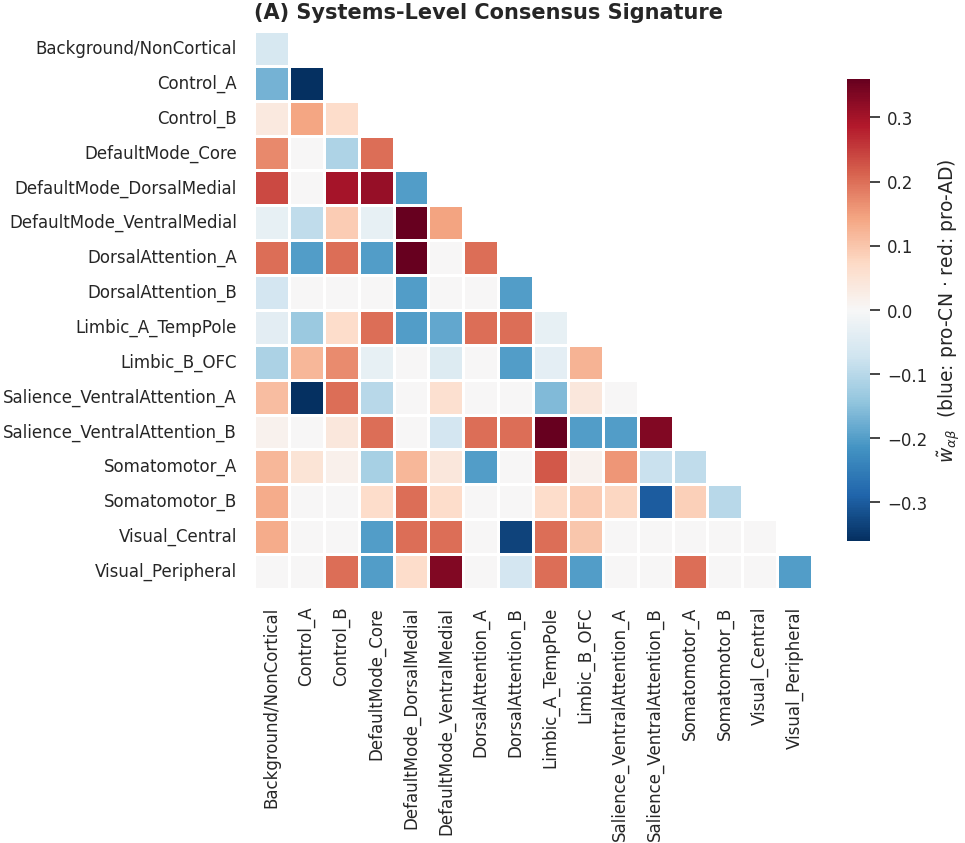

[§5b] Fig A saved. Networks: ['Background/NonCortical', 'Control_A', 'Control_B', 'DefaultMode_Core', 'DefaultMode_DorsalMedial', 'DefaultMode_VentralMedial', 'DorsalAttention_A', 'DorsalAttention_B', 'Limbic_A_TempPole', 'Limbic_B_OFC', 'Salience_VentralAttention_A', 'Salience_VentralAttention_B', 'Somatomotor_A', 'Somatomotor_B', 'Visual_Central', 'Visual_Peripheral']


In [6]:
# ─── §5b — (A) Systems-Level Consensus Signature (Network × Network) ────────

# Map connection_id → (net_src, net_dst) via roi2net
meta_conn = (
    df_full[["connection_id", "src_AAL3_Name", "dst_AAL3_Name"]]
    .drop_duplicates("connection_id")
    .set_index("connection_id")
)
meta_conn = _force_tuple_index(meta_conn)
meta_conn["src_net"] = meta_conn["src_AAL3_Name"].map(roi2net)
meta_conn["dst_net"] = meta_conn["dst_AAL3_Name"].map(roi2net)

# Join stability with network info
stab_net = (
    df_stability
    .join(meta_conn[["src_net", "dst_net"]], how="inner")
    .dropna(subset=["src_net", "dst_net"])
    .copy()
)
stab_net["net_pair"] = [tuple(sorted(x)) for x in zip(stab_net["src_net"], stab_net["dst_net"])]

# Weighted score per network pair:
#   w̃(α,β) = Σ_e(w_signed_e · stability_mag_e) / Σ_e(stability_mag_e)
def _weighted_score(g):
    den = g["stability_mag"].sum()
    return float((g["w_signed"] * g["stability_mag"]).sum() / den) if den > 0 else 0.0

net_scores = stab_net.groupby("net_pair", observed=True).apply(_weighted_score)
net_scores.name = "score"

# Build symmetric matrix
nets = sorted({n for pair in net_scores.index for n in pair})
mat_A = pd.DataFrame(0.0, index=nets, columns=nets)
for (na, nb), val in net_scores.items():
    mat_A.loc[na, nb] = val
    mat_A.loc[nb, na] = val

# Lower-triangle heatmap
vmax = np.percentile(np.abs(mat_A.values), 98)
if not np.isfinite(vmax) or vmax <= 1e-6: vmax = 1.0
mask_upper = np.triu(np.ones_like(mat_A, dtype=bool), k=1)

fig_A, ax_A = plt.subplots(figsize=(6, 5))
hm = sns.heatmap(
    mat_A, mask=mask_upper, cmap="RdBu_r",
    vmin=-vmax, vmax=vmax, center=0.0, square=True,
    linewidths=0.5, linecolor="white",
    cbar_kws={"label": r"$\tilde{w}_{\alpha\beta}$  (blue: pro-CN · red: pro-AD)", "shrink": 0.8},
    ax=ax_A,
)
ax_A.set_title("(A) Systems-Level Consensus Signature", loc="left", weight="bold")
ax_A.tick_params(axis="x", rotation=90)
ax_A.tick_params(axis="y", rotation=0)
savefig_nature(fig_A, FIG_DIR / "fig_systems_signature")
if SHOW_FIGURES: plt.show()
else: plt.close(fig_A)
print(f"[§5b] Fig A saved. Networks: {nets}")


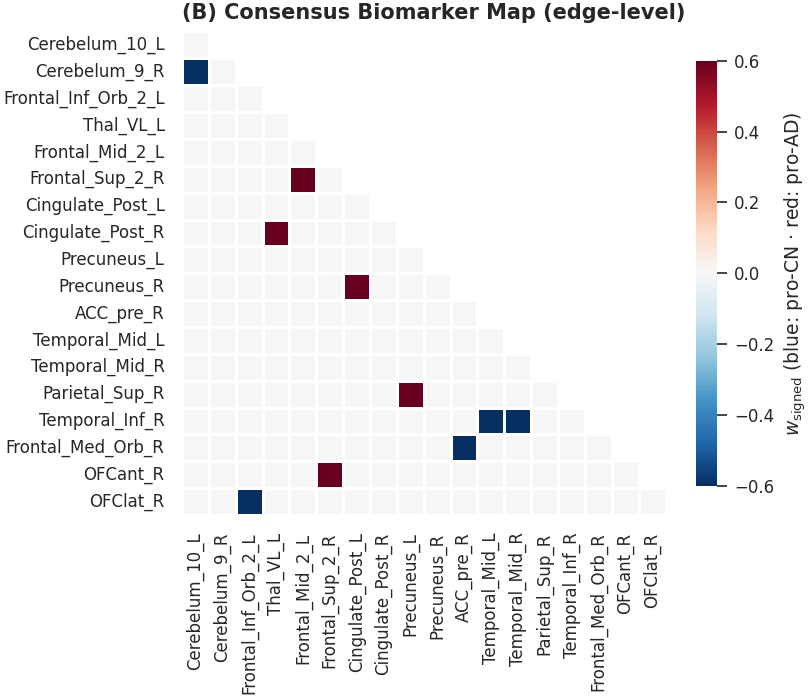

[§5c] Fig B saved. 18 ROIs in consensus.


In [7]:
# ─── §5c — (B) Consensus Biomarker Map (ROI × ROI) ──────────────────────────

w_edges = consensus_set["w_signed"].copy()
if w_edges.empty:
    print("[§5c] Consensus set is empty — skipping biomarker map.")
else:
    # ROIs in consensus, ordered by network then name
    rois_in_cons = sorted({roi for conn in w_edges.index for roi in conn})
    _roi_df = pd.DataFrame({
        "ROI": rois_in_cons,
        "Network": [roi2net.get(r, "Unknown") for r in rois_in_cons],
    }).sort_values(["Network", "ROI"])
    ordered_rois = _roi_df["ROI"].tolist()

    # ROI×ROI matrix (symmetric, consensus edges only)
    mat_B = pd.DataFrame(0.0, index=ordered_rois, columns=ordered_rois)
    for (ra, rb), w in w_edges.items():
        if ra in mat_B.index and rb in mat_B.columns:
            mat_B.loc[ra, rb] = w
            mat_B.loc[rb, ra] = w

    mask_up = np.triu(np.ones_like(mat_B, dtype=bool), k=1)
    vals = mat_B.values[~mask_up]
    abs_vals = np.abs(vals[vals != 0])
    vmax_B = float(np.percentile(abs_vals, 98)) if abs_vals.size else 1.0
    if vmax_B <= 1e-6: vmax_B = 1.0

    fig_B, ax_B = plt.subplots(figsize=(5.2, 4.6))
    sns.heatmap(
        mat_B, mask=mask_up, cmap="RdBu_r",
        vmin=-vmax_B, vmax=vmax_B, center=0.0, square=True,
        linewidths=0.5, linecolor="white",
        cbar_kws={"label": r"$w_{\mathrm{signed}}$ (blue: pro-CN · red: pro-AD)", "shrink": 0.8},
        ax=ax_B, annot=False,
    )
    ax_B.set_title("(B) Consensus Biomarker Map (edge-level)", loc="left", weight="bold")
    ax_B.tick_params(axis="x", rotation=90)
    ax_B.tick_params(axis="y", rotation=0)

    savefig_nature(fig_B, FIG_DIR / "fig_consensus_edges_roi")
    if SHOW_FIGURES: plt.show()
    else: plt.close(fig_B)
    print(f"[§5c] Fig B saved. {len(ordered_rois)} ROIs in consensus.")


[§6] L/R edges for lateralization: 38130


,TopK,n_folds,mean_p_RR,std_p_RR,t_stat,p_value
0,50,5,0.551868,0.139834,0.829408,0.453501
1,100,5,0.539563,0.106834,0.828077,0.454173
2,200,5,0.544355,0.091912,1.079094,0.341272


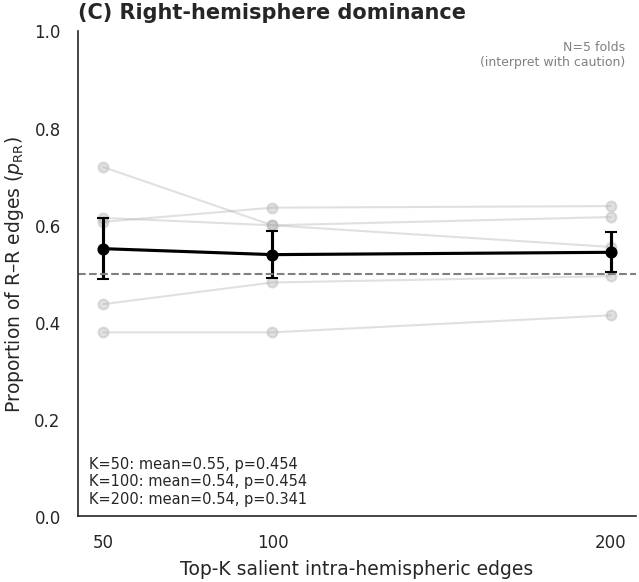

[§6] Lateralization figure saved.


In [8]:
# ─── §6 — Right-hemisphere dominance ──────────────────────────────────────────

df_lat_clean = df_full.query("hemi_src in ['L','R'] and hemi_dst in ['L','R']").copy()
print(f"[§6] L/R edges for lateralization: {len(df_lat_clean)}")

def p_rr_by_fold(df, K):
    """Proportion of intra-hemispheric R-R edges in top-K, per fold."""
    df_intra = df[df["hemi_src"] == df["hemi_dst"]]
    top = df_intra[df_intra["Rank"] <= K]
    rows = []
    for f, g in top.groupby("fold", observed=True):
        rr = (g["hemi_src"] == "R").sum()
        ll = (g["hemi_src"] == "L").sum()
        n = rr + ll
        rows.append({"fold": int(f), "TopK": K, "RR": rr, "LL": ll, "N": n,
                      "p_RR": (rr / n) if n > 0 else np.nan})
    return pd.DataFrame(rows)

df_lat_plot = pd.concat(
    [p_rr_by_fold(df_lat_clean, K) for K in LATERALIZATION_KS],
    ignore_index=True,
)

# Statistical summary (one-sample t-test vs 0.5)
lat_stats_rows = []
for K in sorted(df_lat_plot["TopK"].unique()):
    vals = df_lat_plot.loc[df_lat_plot["TopK"] == K, "p_RR"].dropna().to_numpy()
    if len(vals) < 2:
        continue
    t, p = ttest_1samp(vals, 0.5)
    lat_stats_rows.append({
        "TopK": K, "n_folds": len(vals),
        "mean_p_RR": float(np.mean(vals)),
        "std_p_RR": float(np.std(vals, ddof=1)),
        "t_stat": float(t), "p_value": float(p),
    })

df_lat_stats = pd.DataFrame(lat_stats_rows)
df_lat_stats.to_csv(TBL_DIR / "table_lateralization.csv", index=False)
df_lat_plot.to_csv(TBL_DIR / "table_lateralization_by_fold.csv", index=False)

display(df_lat_stats)

# Figure
fig_C, ax_C = plt.subplots(figsize=(4.8, 4.2))

for f, g in df_lat_plot.groupby("fold", observed=True):
    ax_C.plot(g["TopK"], g["p_RR"], "o-", alpha=0.4, lw=1.0, color="0.7")

Ks = df_lat_stats["TopK"].to_numpy()
means = df_lat_stats["mean_p_RR"].to_numpy()
sems = df_lat_stats["std_p_RR"].to_numpy() / np.sqrt(df_lat_stats["n_folds"].to_numpy())
ax_C.errorbar(Ks, means, yerr=sems, fmt="o-", lw=1.5, color="black", capsize=3, label="Mean ± SEM")
ax_C.axhline(0.5, color="grey", ls="--", lw=1)

ax_C.set_title("(C) Right-hemisphere dominance", loc="left", weight="bold")
ax_C.set_xlabel("Top-K salient intra-hemispheric edges")
ax_C.set_ylabel(r"Proportion of R–R edges ($p_{\mathrm{RR}}$)")
ax_C.set_xticks(sorted(df_lat_plot["TopK"].unique()))
ax_C.set_ylim(0.0, 1.0)

# Annotate p-values
txt = "\n".join(f"K={int(r['TopK'])}: mean={r['mean_p_RR']:.2f}, p={r['p_value']:.3f}"
                for _, r in df_lat_stats.iterrows())
ax_C.text(0.02, 0.02, txt, transform=ax_C.transAxes, fontsize=7, va="bottom", ha="left",
          bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

# Caveat for small N
if N_FOLDS < 10:
    ax_C.text(0.98, 0.98, f"N={N_FOLDS} folds\n(interpret with caution)",
              transform=ax_C.transAxes, fontsize=6, va="top", ha="right", color="gray")

savefig_nature(fig_C, FIG_DIR / "fig_lateralization")
if SHOW_FIGURES: plt.show()
else: plt.close(fig_C)
print(f"[§6] Lateralization figure saved.")


In [9]:
# ─── §7a — Cohen's d per edge (TEST sets only, fold-level) ──────────────────

_SKIP_EFFECT_SIZE = GLOBAL_TENSOR_PATH is None or not GLOBAL_TENSOR_PATH.exists()

if _SKIP_EFFECT_SIZE:
    print("[§7a] GLOBAL_TENSOR_PATH not available — skipping Cohen's d. "
          "Set GLOBAL_TENSOR_PATH in §1 to enable.")
    df_cohen_all = None
else:
    # Load tensor (selected channels, mean across them)
    _npz = np.load(GLOBAL_TENSOR_PATH)
    global_tensor_data = _npz["global_tensor_data"]  # [n_subj, n_ch, R, R]
    subject_ids_all = _npz["subject_ids"].astype(str)

    tensor_sel = global_tensor_data[:, CHANNELS_TO_USE, :, :]  # [n, C_sel, R, R]
    tensor_mean = tensor_sel.mean(axis=1)  # [n, R, R]

    def cohen_d(ad, cn, eps=1e-9):
        """Cohen's d (AD − CN) with pooled std."""
        ad, cn = np.asarray(ad, float), np.asarray(cn, float)
        nx, ny = ad.size, cn.size
        if nx < 2 or ny < 2: return np.nan
        s_ad, s_cn = np.var(ad, ddof=1), np.var(cn, ddof=1)
        pooled = np.sqrt(((nx-1)*s_ad + (ny-1)*s_cn) / max(nx+ny-2, 1))
        return float((ad.mean() - cn.mean()) / pooled) if pooled > eps else 0.0

    cohen_per_fold = []
    for f in FOLDS:
        fi = fold_indices[f]
        test_tidx = fi["test_tensor_idx"]
        test_labels = fi["test_labels"]

        ad_idx = test_tidx[test_labels == "AD"]
        cn_idx = test_tidx[test_labels == "CN"]

        if len(ad_idx) < 2 or len(cn_idx) < 2:
            print(f"[§7a][WARN] Fold {f}: too few AD/CN in test; skipped.")
            continue

        rows = []
        for conn, i, j in conn_map.itertuples():
            vals = tensor_mean[:, i, j]
            d = cohen_d(vals[ad_idx], vals[cn_idx])
            rows.append((conn, d))

        df_fold_d = (
            pd.DataFrame(rows, columns=["connection_id", f"cohen_d_fold_{f}"])
            .set_index("connection_id")
        )
        cohen_per_fold.append(df_fold_d)

    if not cohen_per_fold:
        raise RuntimeError("[§7a] Could not compute Cohen's d in any fold.")

    df_cohen_all = pd.concat(cohen_per_fold, axis=1)
    df_cohen_all = _force_tuple_index(df_cohen_all)
    df_cohen_all["mean_cohen_d"] = df_cohen_all.mean(axis=1, skipna=True)
    df_cohen_all["std_cohen_d"]  = df_cohen_all.std(axis=1, skipna=True)

    # Export
    _dc = df_cohen_all.reset_index()
    _dc["ROI_src"] = _dc["connection_id"].apply(lambda x: x[0])
    _dc["ROI_dst"] = _dc["connection_id"].apply(lambda x: x[1])
    _dc.to_csv(TBL_DIR / "table_effectsize_cohen_d_by_fold.csv", index=False)

    _summary = _dc[["connection_id", "ROI_src", "ROI_dst", "mean_cohen_d", "std_cohen_d"]].copy()
    _summary.to_csv(TBL_DIR / "table_effectsize_cohen_d_summary.csv", index=False)

    print(f"[§7a] Cohen's d computed for {df_cohen_all['mean_cohen_d'].notna().sum()} edges "
          f"across {len(cohen_per_fold)} folds.")
    print(f"       Feature: {EFFECT_CHANNEL_AGG} of channels {CHANNELS_TO_USE}")


[§7a] Cohen's d computed for 8515 edges across 5 folds.
       Feature: mean_channels of channels [1, 0, 2]


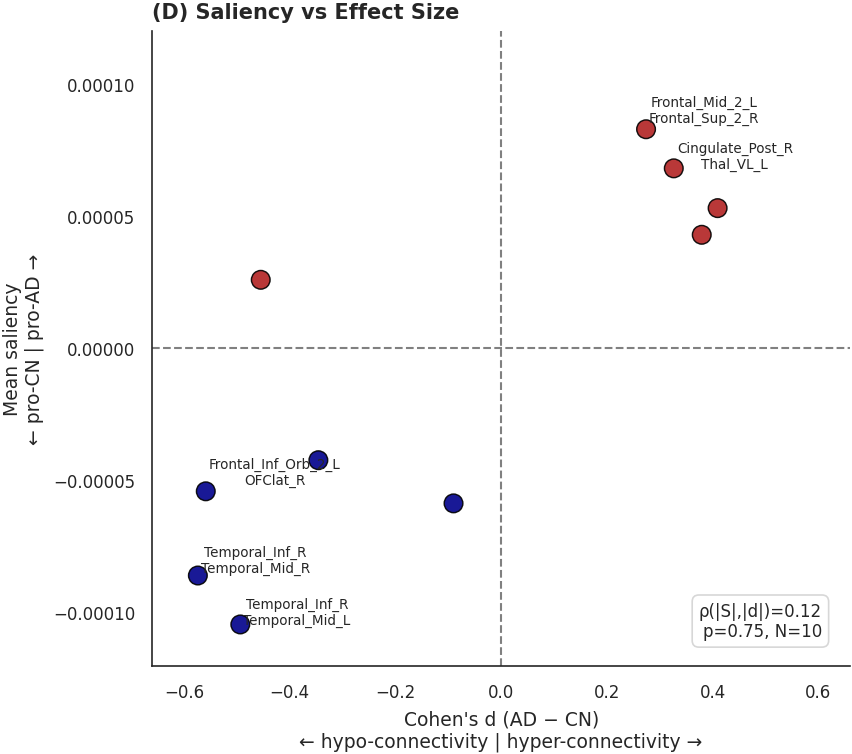

[§7b] Scatter saved. Quadrant distribution:
       Q1: +d,+S (hyper-AD & pro-AD): 4
       Q2: -d,+S (hypo-AD & pro-AD): 1
       Q3: -d,-S (hypo-AD & pro-CN): 5
       Spearman (global):    ρ=0.161, p=1.8e-50, N=8515
       Spearman (consensus): ρ=0.115, p=0.75, N=10


In [10]:
# ─── §7b — (D) Saliency vs Effect Size scatter (quadrants) ──────────────────

if _SKIP_EFFECT_SIZE or df_cohen_all is None:
    print("[§7b] Skipped (no Cohen's d available).")
else:
    try:
        from adjustText import adjust_text
        _HAS_ADJ = True
    except ImportError:
        _HAS_ADJ = False
        def adjust_text(*a, **kw): 
            return

    # Mean saliency per edge across folds
    df_mean_sal = (
        df_full.groupby("connection_id")["Saliency_Signed"]
        .mean().rename("saliency_mean")
    )
    df_mean_sal.index = pd.Index(np.array(list(df_mean_sal.index), dtype=object), name="connection_id")

    cohen_df = df_cohen_all[["mean_cohen_d"]].rename(columns={"mean_cohen_d": "cohen_d"})

    # Restrict to consensus set for the main scatter
    cons_idx = pd.Index(np.array(list(consensus_set.index), dtype=object), name="connection_id")
    df_qc = (
        pd.concat([df_mean_sal, cohen_df], axis=1)
        .dropna()
        .loc[lambda x: x.index.isin(cons_idx)]
    )

    if df_qc.empty:
        print("[§7b] No overlap between consensus and Cohen's d — skipping scatter.")
    else:
        # Quadrant classification
        eps = 1e-8
        sign_d = np.where(df_qc["cohen_d"] > eps, 1, np.where(df_qc["cohen_d"] < -eps, -1, 0))
        sign_s = np.where(df_qc["saliency_mean"] > eps, 1, np.where(df_qc["saliency_mean"] < -eps, -1, 0))

        quad = np.full(len(df_qc), "Axis/near-zero", dtype=object)
        quad[(sign_d > 0) & (sign_s > 0)] = "Q1: +d,+S (hyper-AD & pro-AD)"
        quad[(sign_d < 0) & (sign_s > 0)] = "Q2: -d,+S (hypo-AD & pro-AD)"
        quad[(sign_d < 0) & (sign_s < 0)] = "Q3: -d,-S (hypo-AD & pro-CN)"
        quad[(sign_d > 0) & (sign_s < 0)] = "Q4: +d,-S (hyper-AD & pro-CN)"

        df_qc = df_qc.copy()
        df_qc["quadrant"] = quad
        df_qc["ROI_src"] = [c[0] for c in df_qc.index]
        df_qc["ROI_dst"] = [c[1] for c in df_qc.index]
        df_qc["Network_src"] = df_qc["ROI_src"].map(roi2net)
        df_qc["Network_dst"] = df_qc["ROI_dst"].map(roi2net)
        df_qc.reset_index().to_csv(TBL_DIR / "table_quadrants.csv", index=False)

        # Spearman ρ(|S|, |d|)
        rho, pval = spearmanr(df_qc["saliency_mean"].abs(), df_qc["cohen_d"].abs())

        # Scatter
        fig_D, ax_D = plt.subplots(figsize=(6, 5.5))
        colors = np.where(df_qc["saliency_mean"] > eps, "#B22222", "#00008B")
        ax_D.scatter(df_qc["cohen_d"], df_qc["saliency_mean"], s=80, c=colors,
                     edgecolor="black", linewidth=0.7, alpha=0.9)

        xmax = max(df_qc["cohen_d"].abs().max(), 0.1) * 1.15
        ymax = max(df_qc["saliency_mean"].abs().max(), 1e-4) * 1.15
        ax_D.set_xlim(-xmax, xmax)
        ax_D.set_ylim(-ymax, ymax)
        ax_D.axhline(0, c="gray", ls="--", lw=1)
        ax_D.axvline(0, c="gray", ls="--", lw=1)

        ax_D.set_title("(D) Saliency vs Effect Size", loc="left", weight="bold")
        ax_D.set_xlabel("Cohen's d (AD − CN)\n← hypo-connectivity | hyper-connectivity →")
        ax_D.set_ylabel("Mean saliency\n← pro-CN | pro-AD →")

        ax_D.text(
            0.96, 0.04,
            f"ρ(|S|,|d|)={rho:.2f}\np={pval:.2g}, N={len(df_qc)}",
            transform=ax_D.transAxes, fontsize=8, va="bottom", ha="right",
            bbox=dict(facecolor="white", alpha=0.9, edgecolor="lightgray", boxstyle="round,pad=0.4"),
        )

        # ✅ Label extreme points (FIX: tuple index must be wrapped in a list for .loc)
        top_idx = (
            df_qc["saliency_mean"].nlargest(2).index
            .union(df_qc["saliency_mean"].nsmallest(2).index)
            .union(df_qc["cohen_d"].abs().nlargest(2).index)
        )
        texts = []
        for conn in pd.Index(top_idx).unique():
            if conn not in df_qc.index:
                continue
            r = df_qc.loc[[conn]].iloc[0]   # <-- FIX HERE
            t = ax_D.text(
                r["cohen_d"], r["saliency_mean"],
                f"{conn[0]}\n{conn[1]}",
                fontsize=6.5
            )
            texts.append(t)

        if _HAS_ADJ and texts:
            adjust_text(texts, ax=ax_D, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

        savefig_nature(fig_D, FIG_DIR / "fig_saliency_vs_effect")
        if SHOW_FIGURES:
            plt.show()
        else:
            plt.close(fig_D)

        # Global Spearman
        df_all_global = (
            pd.concat([
                df_mean_sal.abs().rename("absS"),
                df_cohen_all["mean_cohen_d"].abs().rename("absd")
            ], axis=1)
            .dropna()
        )
        rho_g, p_g = spearmanr(df_all_global["absS"], df_all_global["absd"])

        print(f"[§7b] Scatter saved. Quadrant distribution:")
        for q in sorted(df_qc["quadrant"].unique()):
            print(f"       {q}: {(df_qc['quadrant']==q).sum()}")
        print(f"       Spearman (global):    ρ={rho_g:.3f}, p={p_g:.2g}, N={len(df_all_global)}")
        print(f"       Spearman (consensus): ρ={rho:.3f}, p={pval:.2g}, N={len(df_qc)}")

## §8 — Glass Brain & Chord Diagrams

Glass brain requires the AAL3 atlas (NIfTI + ROI list).  
Set `AAL3_DIR` in §1 if available; otherwise this section is skipped gracefully.

Chord diagrams use only `roi_info_from_tensor.csv` (no external atlas needed).


In [11]:
# ─── §8a — Glass brain (optional, requires AAL3 atlas) ──────────────────────

_SKIP_GLASS = True

if AAL3_DIR is not None:
    AAL3_DIR = Path(AAL3_DIR)
    _cand_nii = [AAL3_DIR / "AAL3v1.nii.gz", AAL3_DIR / "AAL3v1.nii",
                 AAL3_DIR / "ROI_MNI_V7.nii"]
    _cand_mat = [AAL3_DIR / "ROI_MNI_V7_List.mat"]
    AAL_NII = next((p for p in _cand_nii if p.exists()), None)
    AAL_MAT = next((p for p in _cand_mat if p.exists()), None)
    if AAL_NII and AAL_MAT:
        _SKIP_GLASS = False

if _SKIP_GLASS:
    print("[§8a] AAL3 atlas not found (AAL3_DIR is None or missing files).")
    print("       To enable glass brain, set AAL3_DIR in §1 pointing to a dir with:")
    print("         - AAL3v1.nii.gz (or AAL3v1.nii)")
    print("         - ROI_MNI_V7_List.mat")
else:
    import nibabel as nib
    from scipy.io import loadmat
    from nilearn.image import new_img_like
    from nilearn.plotting import plot_connectome, plot_glass_brain, find_xyz_cut_coords

    def _canon_roi(s): return re.sub(r"[^A-Za-z0-9]", "", str(s)).upper()

    aal_img = nib.load(str(AAL_NII))
    atlas_data = aal_img.get_fdata().astype(int)
    mat = loadmat(str(AAL_MAT))
    ROI_arr = mat["ROI"]

    name2id, canon2id = {}, {}
    for col in range(ROI_arr.shape[1]):
        item = ROI_arr[0, col]
        idx = int(item["ID"][0][0])
        for nm_key in ["Nom_C", "Nom_L"]:
            nm = str(item[nm_key][0]).strip()
            name2id[nm] = idx
            canon2id[_canon_roi(nm)] = idx

    cons = consensus_set.copy()
    roi_names_cons = sorted({roi for (a, b) in cons.index for roi in (a, b)})

    resolved_ids = {}
    for nm in roi_names_cons:
        if nm in name2id: resolved_ids[nm] = name2id[nm]
        elif _canon_roi(nm) in canon2id: resolved_ids[nm] = canon2id[_canon_roi(nm)]

    r_order = [r for r in roi_names_cons if r in resolved_ids]
    coords = []
    for r in r_order:
        mask = (atlas_data == int(resolved_ids[r])).astype(np.int32)
        coords.append(find_xyz_cut_coords(new_img_like(aal_img, mask)))

    # Adjacency matrix
    pos_map = {r: i for i, r in enumerate(r_order)}
    A = np.zeros((len(r_order), len(r_order)), dtype=float)
    for (a, b), row in cons.iterrows():
        if a in pos_map and b in pos_map:
            i, j = pos_map[a], pos_map[b]
            A[i, j] = A[j, i] = float(row["w_signed"])

    node_str = np.abs(A).sum(axis=1)
    S = (node_str - node_str.min()) / (node_str.max() - node_str.min() + 1e-12)
    node_sizes = np.clip(14 + 56 * np.sqrt(S), 14, 70)

    vmax_gl = float(np.abs(A).max())
    fig_gl = plt.figure(figsize=(8.4, 5.8))
    plot_connectome(A, coords, node_color="black", node_size=node_sizes,
                    edge_cmap="RdBu_r", edge_vmin=-vmax_gl, edge_vmax=vmax_gl,
                    colorbar=True, display_mode="lyrz", figure=fig_gl)
    plt.suptitle("Consensus connectome (AD vs CN)", y=0.99, fontsize=11, weight="bold")
    savefig_nature(fig_gl, FIG_DIR / "fig_glass_brain_consensus")
    if SHOW_FIGURES: plt.show()
    else: plt.close(fig_gl)
    print(f"[§8a] Glass brain saved ({len(r_order)} nodes, {int(np.any(A, axis=1).sum())} with edges).")


[§8a] AAL3 atlas not found (AAL3_DIR is None or missing files).
       To enable glass brain, set AAL3_DIR in §1 pointing to a dir with:
         - AAL3v1.nii.gz (or AAL3v1.nii)
         - ROI_MNI_V7_List.mat


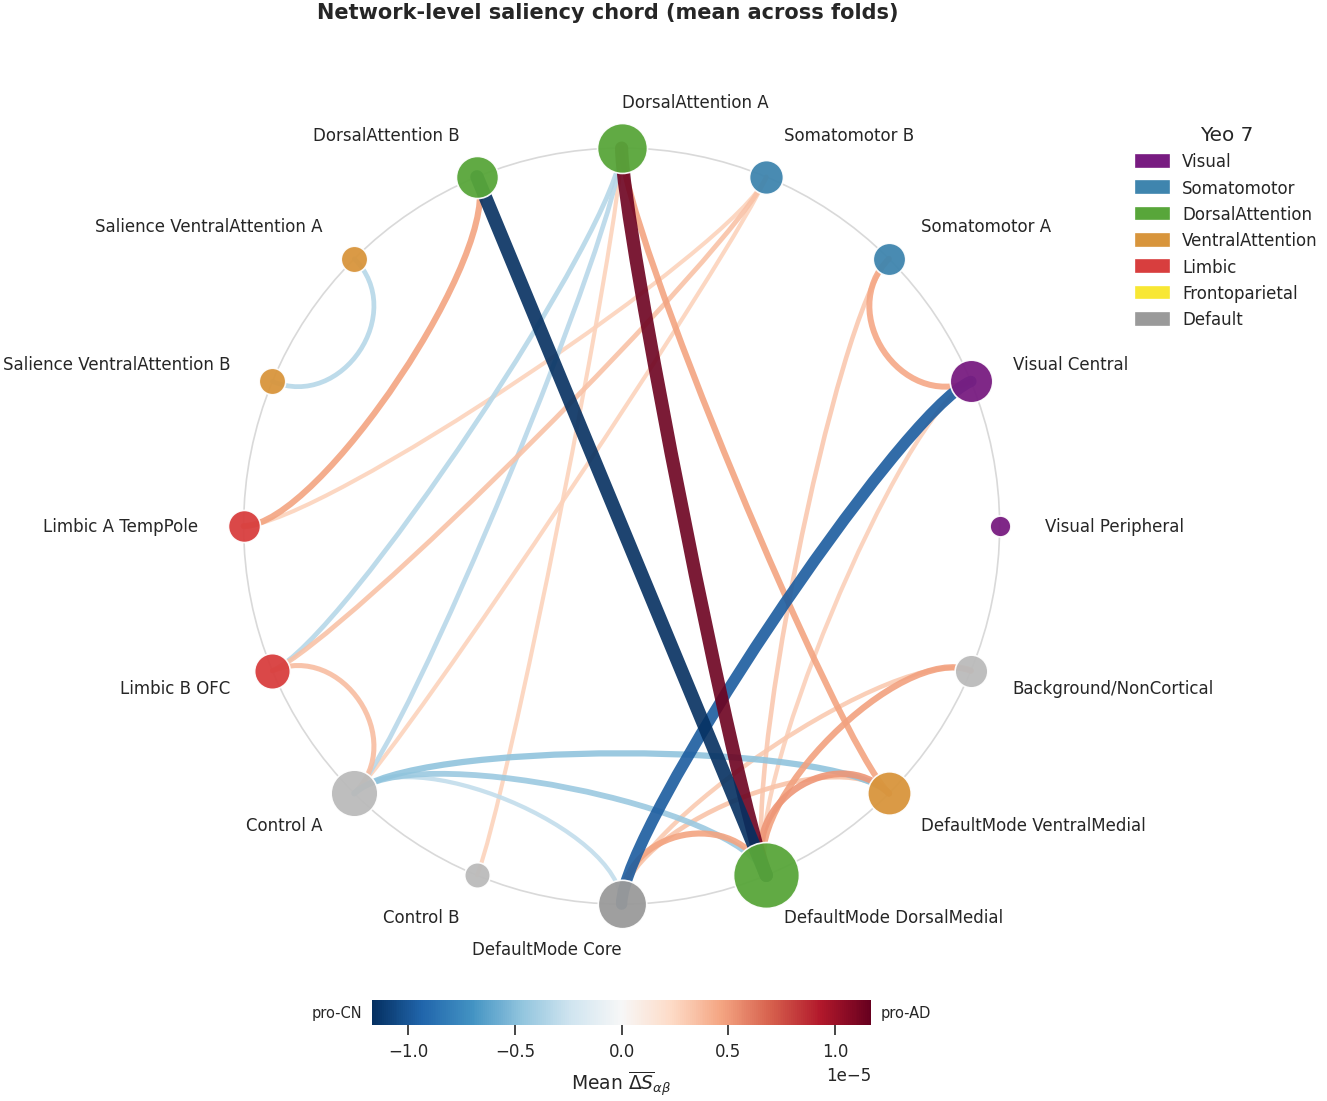

[§8b] Chord network saved (24 edges, 16 networks).


In [12]:
# ─── §8b — Chord diagram: Network × Network ────────────────────────────────
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch, Circle
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

# ── Helpers ──────────────────────────────────────────────────────────────────
YEO7_CANON = ["Visual", "Somatomotor", "DorsalAttention", "VentralAttention",
              "Limbic", "Frontoparietal", "Default"]
YEO_CMAP = {
    "visual": "#781C81", "somato": "#3F85AE", "dorsal": "#58A63A",
    "ventral": "#D8953C", "limbic": "#D83E3E", "fronto": "#F8E734",
    "default": "#9A9A9A",
}

def _guess_yeo_color(name, default="#BBBBBB"):
    n = str(name).lower()
    for k, c in YEO_CMAP.items():
        if k in n: return c
    return default

def _bezier_chord(ax, p1, p2, lw, color, alpha=0.9, inset=0.80):
    ctrl1, ctrl2 = p1 * inset, p2 * inset
    path = MplPath([p1, ctrl1, ctrl2, p2],
                   [MplPath.MOVETO, MplPath.CURVE4, MplPath.CURVE4, MplPath.CURVE4])
    ax.add_patch(PathPatch(path, facecolor="none", edgecolor=color,
                           lw=lw, alpha=alpha, capstyle="round"))

# ── Derive network order from roi_info_from_tensor.csv (no external CSV) ────
# roi_info_df already has roi_name_in_tensor, network_label_in_tensor  (from §3)
_net_first = (roi_info_df.reset_index()
              .groupby("network_label_in_tensor")
              .first()["index"]
              .sort_values())
_net_order_all = _net_first.index.tolist()

# ── Build network×network saliency matrix ───────────────────────────────────
ns = "src_Refined_Network" if "src_Refined_Network" in df_full.columns else "src_Yeo17_Network"
nd = "dst_Refined_Network" if "dst_Refined_Network" in df_full.columns else "dst_Yeo17_Network"
mat_net = (df_full.groupby([ns, nd])["Saliency_Signed"].mean()
           .unstack(fill_value=0.0))
mat_net = (mat_net + mat_net.T) / 2.0

networks_present = sorted(mat_net.index.union(mat_net.columns))
mat_net = mat_net.reindex(index=networks_present, columns=networks_present).fillna(0.0)

# Restrict order to networks actually present
net_order = [n for n in _net_order_all if n in networks_present]
net_order += [n for n in networks_present if n not in net_order]

# Top-K edges
edges_net = []
for i, a in enumerate(networks_present):
    for j, b in enumerate(networks_present):
        if j <= i: continue
        w = float(mat_net.loc[a, b])
        if abs(w) > 0:
            edges_net.append((a, b, w, abs(w)))

k_net = min(CHORD_TOP_K_PAIRS, len(edges_net))
edges_top_net = sorted(edges_net, key=lambda t: t[3], reverse=True)[:k_net]

# Node strength for sizing
_ns_dict = pd.Series(0.0, index=net_order)
for a, b, w, aw in edges_top_net:
    if a in _ns_dict.index: _ns_dict[a] += aw
    if b in _ns_dict.index: _ns_dict[b] += aw

# ── Plot ─────────────────────────────────────────────────────────────────────
R_BASE, R_LABEL = 1.0, 1.12
theta = np.linspace(0, 2*np.pi, len(net_order), endpoint=False)
pos = {n: np.array([R_BASE*np.cos(t), R_BASE*np.sin(t)]) for n, t in zip(net_order, theta)}

vmax_c = np.percentile([aw for *_, aw in edges_top_net], 98) if edges_top_net else 1.0
if vmax_c < 1e-6: vmax_c = 1.0
norm_c = Normalize(vmin=-vmax_c, vmax=vmax_c)
cmap_c = plt.get_cmap("RdBu_r")
max_abs_c = max((aw for *_, aw in edges_top_net), default=1.0)

set_nature_style()
fig_ch, ax_ch = plt.subplots(figsize=(7.2, 7.2))
ax_ch.set_aspect("equal"); ax_ch.axis("off")
ax_ch.add_patch(Circle((0, 0), R_BASE, fc="none", ec="0.85", lw=0.8, zorder=0))

for a, b, w, aw in sorted(edges_top_net, key=lambda t: t[3]):
    _bezier_chord(ax_ch, pos[a], pos[b],
                  lw=float(np.clip(0.6 + 6*(aw/(max_abs_c+1e-12)), 0.6, 6.5)),
                  color=cmap_c(norm_c(w)))

for net in net_order:
    xy = pos[net]
    fc = _guess_yeo_color(net)
    ns_max = _ns_dict.max() if _ns_dict.max() > 0 else 1.0
    sz = 100 + 900*(_ns_dict.get(net, 0)/ns_max)
    ax_ch.scatter([xy[0]], [xy[1]], s=sz, color=fc, edgecolor="white", lw=0.8, zorder=5, alpha=0.95)
    ang = np.arctan2(xy[1], xy[0])
    lx, ly = R_LABEL*np.cos(ang), R_LABEL*np.sin(ang)
    ax_ch.text(lx, ly, str(net).replace("_", " "), fontsize=8,
               ha="left" if lx >= 0 else "right", va="center")

# Legend
_key_map = {"Visual": "visual", "Somatomotor": "somato", "DorsalAttention": "dorsal",
            "VentralAttention": "ventral", "Limbic": "limbic", "Frontoparietal": "fronto",
            "Default": "default"}
ax_ch.legend(handles=[mpatches.Patch(color=YEO_CMAP[_key_map[n]], label=n) for n in YEO7_CANON if _key_map[n] in YEO_CMAP],
             title="Yeo 7", bbox_to_anchor=(1.1, 1.0), loc="upper left", fontsize=8, frameon=False)

sm = ScalarMappable(norm=norm_c, cmap=cmap_c); sm.set_array([])
cax = inset_axes(ax_ch, width="60%", height="3%", loc="lower center", borderpad=-5)
cbar = fig_ch.colorbar(sm, cax=cax, orientation="horizontal")
cbar.set_label(r"Mean $\overline{\Delta S}_{\alpha\beta}$", fontsize=9)
cbar.outline.set_visible(False)
cbar.ax.text( 1.02, 0.5, "pro-AD", transform=cbar.ax.transAxes, ha="left",  va="center", fontsize=7)
cbar.ax.text(-0.02, 0.5, "pro-CN", transform=cbar.ax.transAxes, ha="right", va="center", fontsize=7)

plt.suptitle("Network-level saliency chord (mean across folds)", y=0.98, fontsize=10, weight="bold")
savefig_nature(fig_ch, FIG_DIR / "fig_chord_network")
if SHOW_FIGURES: plt.show()
else: plt.close(fig_ch)
print(f"[§8b] Chord network saved ({k_net} edges, {len(net_order)} networks).")


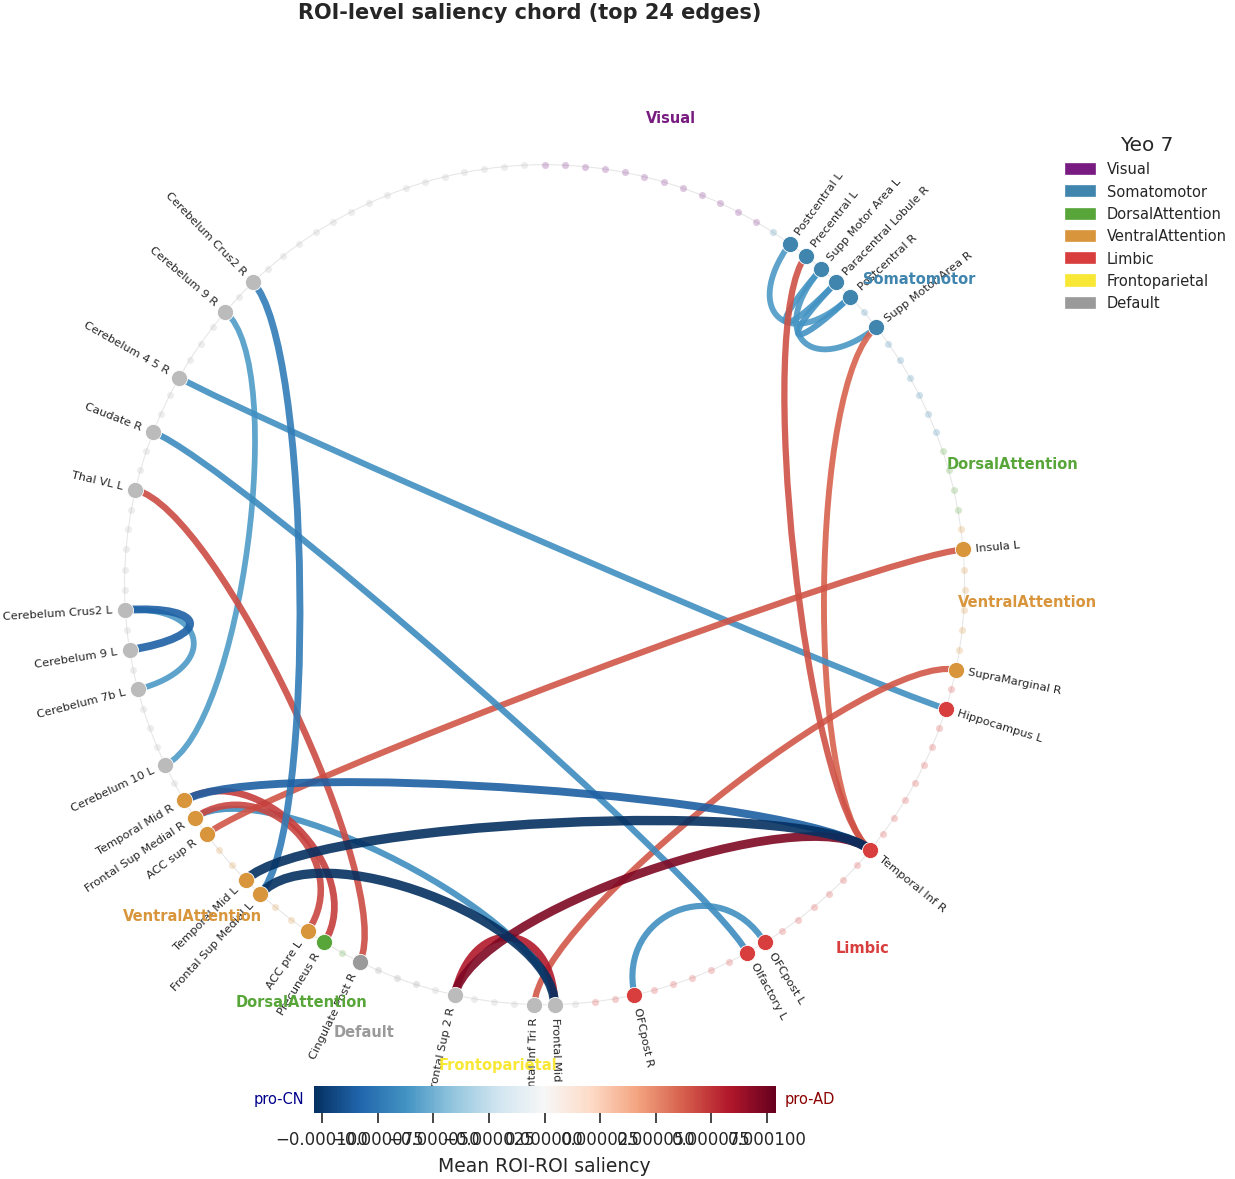

[§8c] Chord ROI saved (24 edges, 33 ROIs labeled).


In [13]:
# ─── §8c — Chord diagram: ROI × ROI ─────────────────────────────────────────
# Uses roi_info_from_tensor.csv ordering (no external CSV).

def _broad_yeo(name):
    n = str(name).lower()
    for cand, label in [("visual", "Visual"), ("somato", "Somatomotor"),
                         ("dorsal", "DorsalAttention"), ("ventral", "VentralAttention"),
                         ("salience", "VentralAttention"), ("limbic", "Limbic"),
                         ("fronto", "Frontoparietal"), ("control", "Frontoparietal"),
                         ("default", "Default")]:
        if cand in n: return label
    return "Other"

# Build ROI-level ordering from roi_info (already sorted by tensor index)
_roi_meta = roi_info_df.copy()
_roi_meta["broad_yeo"] = _roi_meta["network_label_in_tensor"].map(_broad_yeo)
_roi_meta["color"] = _roi_meta["network_label_in_tensor"].map(_guess_yeo_color)
roi_order_chord = _roi_meta["roi_name_in_tensor"].tolist()  # already sorted

# ROI-level mean saliency
_df_roi = df_full.groupby(["src_AAL3_Name", "dst_AAL3_Name"])["Saliency_Signed"].mean()

# Build edges
edges_roi = []
for (src, dst), w in _df_roi.items():
    if src in roi_order_chord and dst in roi_order_chord and src != dst:
        if abs(w) > 0:
            edges_roi.append((src, dst, w, abs(w)))

k_roi = min(CHORD_TOP_K_ROI, len(edges_roi))
edges_top_roi = sorted(edges_roi, key=lambda t: t[3], reverse=True)[:k_roi]

# Positions
n_rois_ch = len(roi_order_chord)
thetas_roi = np.linspace(np.pi/2, np.pi/2 - 2*np.pi, n_rois_ch, endpoint=False)
R_B, R_T = 1.0, 1.03
pos_roi = {nm: np.array([R_B*np.cos(t), R_B*np.sin(t)])
            for nm, t in zip(roi_order_chord, thetas_roi)}

rois_with_edges = {r for (a, b, *_) in edges_top_roi for r in (a, b)}

vmax_r = np.percentile([aw for *_, aw in edges_top_roi], 98) if edges_top_roi else 1.0
if vmax_r < 1e-6: vmax_r = 1.0
norm_r = Normalize(vmin=-vmax_r, vmax=vmax_r)
cmap_r = plt.get_cmap("RdBu_r")
max_abs_r = max((aw for *_, aw in edges_top_roi), default=1.0)

set_nature_style()
fig_cr, ax_cr = plt.subplots(figsize=(8, 8))
ax_cr.set_aspect("equal"); ax_cr.axis("off")
ax_cr.add_patch(Circle((0, 0), R_B, fc="none", ec="0.9", lw=0.5, zorder=0))

# Chords
for s, d, w, aw in sorted(edges_top_roi, key=lambda t: t[3]):
    _bezier_chord(ax_cr, pos_roi[s], pos_roi[d],
                  lw=float(np.clip(0.5 + 4*(aw/(max_abs_r + 1e-12)), 0.5, 5)),
                  color=cmap_r(norm_r(w)), inset=0.80)

# Nodes
for rname in roi_order_chord:
    xy = pos_roi[rname]
    fc = _roi_meta.loc[_roi_meta["roi_name_in_tensor"] == rname, "color"].iloc[0]
    active = rname in rois_with_edges
    ax_cr.scatter([xy[0]], [xy[1]], s=60 if active else 12,
                  color=fc, edgecolor="white", lw=0.4,
                  zorder=10 if active else 5, alpha=1.0 if active else 0.25)
    if active:
        t = thetas_roi[roi_order_chord.index(rname)]
        rot = np.degrees(t)
        ha = "right" if (90 < rot % 360 < 270) else "left"
        if 90 < rot % 360 < 270: rot += 180
        lx, ly = R_T*np.cos(t), R_T*np.sin(t)
        ax_cr.text(lx, ly, rname.replace("_", " "), rotation=rot,
                   ha=ha, va="center", fontsize=5.5, rotation_mode="anchor")

# Network arc labels
_prev_net, _start = None, 0
for i, rname in enumerate(roi_order_chord + [None]):
    bnet = _roi_meta.loc[_roi_meta["roi_name_in_tensor"] == rname, "broad_yeo"].iloc[0] if rname else "END"
    if bnet != _prev_net:
        if _prev_net is not None and _prev_net != "Other":
            mid_t = (thetas_roi[_start] + thetas_roi[min(i-1, n_rois_ch-1)]) / 2
            tx, ty = 1.15*np.cos(mid_t), 1.15*np.sin(mid_t)
            ax_cr.text(tx, ty, _prev_net, color=_guess_yeo_color(_prev_net),
                       fontsize=7, weight="bold", ha="center", va="center")
        _prev_net, _start = bnet, i

# Legend + colorbar
ax_cr.legend(handles=[mpatches.Patch(color=YEO_CMAP[_key_map[n]], label=n)
                       for n in YEO7_CANON if _key_map.get(n) in YEO_CMAP],
             title="Yeo 7", loc="upper left", bbox_to_anchor=(1.05, 1), frameon=False, fontsize=7)

sm2 = ScalarMappable(norm=norm_r, cmap=cmap_r); sm2.set_array([])
cax2 = inset_axes(ax_cr, width="50%", height="3%", loc="lower center", borderpad=-4)
cbar2 = fig_cr.colorbar(sm2, cax=cax2, orientation="horizontal")
cbar2.set_label("Mean ROI-ROI saliency", fontsize=9)
cbar2.outline.set_visible(False)
cbar2.ax.text( 1.02, 0.5, "pro-AD", transform=cbar2.ax.transAxes, ha="left",  va="center", fontsize=7, color="#8B0000")
cbar2.ax.text(-0.02, 0.5, "pro-CN", transform=cbar2.ax.transAxes, ha="right", va="center", fontsize=7, color="#00008B")

plt.suptitle(f"ROI-level saliency chord (top {k_roi} edges)", fontsize=10, y=0.98, weight="bold")
savefig_nature(fig_cr, FIG_DIR / "fig_chord_roi")
if SHOW_FIGURES: plt.show()
else: plt.close(fig_cr)
print(f"[§8c] Chord ROI saved ({k_roi} edges, {len(rois_with_edges)} ROIs labeled).")


In [14]:
# ─── §IT — Information-theoretic summary + table exports ─────────────────────
from scipy.stats import spearmanr, entropy as sp_entropy

# ═══════ A) Fold-level entropy of edge selection frequency ═══════════════════
# H(EdgeSelected): using π (recurrence probability) as the "empirical pmf" proxy
# Higher H → more uniform selection → more diverse saliency landscape

it_rows = []

# π values from df_stability (one row per connection)
if "pi" in df_stability.columns:
    pi_vals = df_stability["pi"].dropna().to_numpy()
    # Normalise to a valid pmf
    pi_pmf = pi_vals / (pi_vals.sum() + 1e-30)
    H_pi = float(sp_entropy(pi_pmf, base=2))
    n_nonzero = int((pi_vals > 0).sum())
    H_max = float(np.log2(n_nonzero)) if n_nonzero > 1 else 0.0
    it_rows.append({
        "measure": "H(pi_edge)",
        "value_bits": round(H_pi, 4),
        "H_max_bits": round(H_max, 4),
        "normalised_H": round(H_pi / (H_max + 1e-30), 4),
        "N_edges": len(pi_vals),
        "note": "Entropy of recurrence probability distribution",
    })
    print(f"[§IT] H(pi) = {H_pi:.4f} bits  |  H_max = {H_max:.4f}  |  norm = {H_pi/(H_max+1e-30):.4f}")
else:
    print("[§IT] pi column not found in df_stability — skipping entropy.")

# ═══════ B) SHAP MI (optional) ══════════════════════════════════════════════
# If shap_pack joblib files exist, compute MI(attribution_bin; diagnosis)
_shap_files = list(RUN_DIR.glob("fold_*/interpretability_shap/shap_pack_*.joblib"))
if _shap_files:
    import joblib
    from sklearn.metrics import mutual_info_score

    for sf in sorted(_shap_files):
        try:
            pack = joblib.load(sf)
            # Expected keys: shap_values (array), labels (array)
            if hasattr(pack, "keys"):
                vals = pack.get("shap_values", pack.get("values", None))
                labs = pack.get("labels", pack.get("y", None))
            else:
                continue
            if vals is None or labs is None:
                continue
            # Flatten to per-sample summary (mean abs shap)
            if vals.ndim > 1:
                summary = np.abs(vals).mean(axis=tuple(range(1, vals.ndim)))
            else:
                summary = np.abs(vals)
            # Quantile-bin the summary into 4 bins
            bins = pd.qcut(summary, q=4, labels=False, duplicates="drop")
            mi = mutual_info_score(labs, bins) / np.log(2)  # convert nats→bits
            fold_tag = sf.parent.parent.name
            it_rows.append({
                "measure": f"MI(shap_bin;dx)_{fold_tag}_{sf.stem}",
                "value_bits": round(float(mi), 6),
                "H_max_bits": np.nan,
                "normalised_H": np.nan,
                "N_edges": len(summary),
                "note": f"MI from {sf.stem} ({fold_tag}), 4 quantile bins",
            })
        except Exception as e:
            print(f"  [SHAP-MI] Could not load {sf.name}: {e}")
    print(f"[§IT] Processed {len(_shap_files)} SHAP packs.")
else:
    print("[§IT] No SHAP joblib files found — SHAP MI skipped.")

df_it = pd.DataFrame(it_rows)
if not df_it.empty:
    df_it.to_csv(TBL_DIR / "table_information_theory.csv", index=False)
    display(df_it)
    print(f"[§IT] Information theory table saved ({len(df_it)} rows).")
else:
    print("[§IT] No IT measures computed.")

# ═══════ C) Export master tables ═════════════════════════════════════════════

# C1) Consensus edges table (with Cohen's d if available)
meta_conn = (df_full[["connection_id", "src_AAL3_Name", "dst_AAL3_Name"]]
             .drop_duplicates("connection_id").copy())
meta_conn["connection_id"] = meta_conn["connection_id"].apply(
    lambda x: tuple(x) if isinstance(x, (list, np.ndarray)) else x)
meta_conn = meta_conn.rename(columns={"src_AAL3_Name": "ROI_src", "dst_AAL3_Name": "ROI_dst"})
meta_conn["Network_src"] = meta_conn["ROI_src"].map(roi2net)
meta_conn["Network_dst"] = meta_conn["ROI_dst"].map(roi2net)

cons_df = _force_tuple_index(consensus_set, "connection_id").reset_index()
consensus_export = cons_df.merge(meta_conn, on="connection_id", how="left")

if not _SKIP_EFFECT_SIZE:
    cohen_exp = (_force_tuple_index(df_cohen_all[["mean_cohen_d", "std_cohen_d"]], "connection_id")
                 .reset_index()
                 .rename(columns={"mean_cohen_d": "Cohen_d", "std_cohen_d": "Cohen_d_std"}))
    consensus_export = consensus_export.merge(cohen_exp, on="connection_id", how="left")

_pref = ["ROI_src", "ROI_dst", "Network_src", "Network_dst",
         "pi", "tau", "signedness", "stability_mag", "w_signed"]
cols_out = [c for c in _pref if c in consensus_export.columns]
cols_out += [c for c in consensus_export.columns if c not in cols_out]
consensus_export[cols_out].to_csv(TBL_DIR / "Table_ConsensusEdges_signature.csv", index=False)
print(f"[§IT] Consensus table saved ({len(consensus_export)} edges).")

# C2) Lateralization (already saved in §6)
print(f"[§IT] Lateralization tables: {TBL_DIR / 'table_lateralization.csv'}")

# C3) Spearman |S| vs |d|
if not _SKIP_EFFECT_SIZE:
    absS = df_full.groupby("connection_id")["Saliency_Signed"].mean().abs().rename("absS")
    absd = df_cohen_all["mean_cohen_d"].abs().rename("absd")
    _df_sp = _force_tuple_index(pd.concat([absS, absd], axis=1).dropna(), "connection_id")
    rho_all, p_all = spearmanr(_df_sp["absS"], _df_sp["absd"])
    cons_idx = _force_tuple_index(consensus_set, "connection_id").index
    _df_cons_sp = _df_sp.loc[_df_sp.index.intersection(cons_idx)]
    rho_cons = p_cons = np.nan
    if len(_df_cons_sp) >= 3:
        rho_cons, p_cons = spearmanr(_df_cons_sp["absS"], _df_cons_sp["absd"])
    with open(TBL_DIR / "Summary_Spearman_saliency_vs_effect.txt", "w") as f:
        f.write(f"GLOBAL  rho={rho_all:.6f}  p={p_all:.3g}  N={len(_df_sp)}\n")
        f.write(f"CONSENSUS rho={rho_cons:.6f}  p={p_cons:.3g}  N={len(_df_cons_sp)}\n")
    print(f"[§IT] Spearman: global rho={rho_all:.3f}, consensus rho={rho_cons:.3f}")
else:
    print("[§IT] Effect-size skipped → Spearman not exported.")


[§IT] H(pi) = 9.9080 bits  |  H_max = 10.0028  |  norm = 0.9905
[§IT] Processed 10 SHAP packs.


,measure,value_bits,H_max_bits,normalised_H,N_edges,note
0,H(pi_edge),9.908,10.0028,0.9905,8515,Entropy of recurrence probability distribution


[§IT] Information theory table saved (1 rows).
[§IT] Consensus table saved (10 edges).
[§IT] Lateralization tables: /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/further_analysis_paper_output/Tables/table_lateralization.csv
[§IT] Spearman: global rho=0.161, consensus rho=0.115


In [15]:
# ─── §F — Outputs index & final checklist ─────────────────────────────────────

# Walk OUTPUT_DIR and build a manifest of all files produced by this notebook.
rows_idx = []
for fp in sorted(OUTPUT_DIR.rglob("*")):
    if fp.is_file():
        rows_idx.append({
            "file": str(fp.relative_to(OUTPUT_DIR)),
            "ext": fp.suffix.lower(),
            "size_bytes": fp.stat().st_size,
        })

df_outputs = pd.DataFrame(rows_idx)
if not df_outputs.empty:
    df_outputs.to_csv(OUTPUT_DIR / "outputs_index.csv", index=False)
    print(f"[§F] Outputs index: {len(df_outputs)} files written to {OUTPUT_DIR}")
    display(df_outputs.groupby("ext")["size_bytes"].agg(["count", "sum"]).rename(
        columns={"count": "n_files", "sum": "total_bytes"}).sort_values("n_files", ascending=False))
else:
    print("[§F] No output files found (nothing was saved?).")

# ── Final checklist ──────────────────────────────────────────────────────────
_checks = {
    "FIG_DIR exists": FIG_DIR.is_dir(),
    "TBL_DIR exists": TBL_DIR.is_dir(),
    "consensus table": (TBL_DIR / "Table_ConsensusEdges_signature.csv").exists(),
    "lateralization table": (TBL_DIR / "table_lateralization.csv").exists(),
    "outputs_index.csv": (OUTPUT_DIR / "outputs_index.csv").exists(),
}

print("\n──── Final Checklist ────")
all_ok = True
for label, ok in _checks.items():
    mark = "PASS" if ok else "FAIL"
    if not ok: all_ok = False
    print(f"  [{mark}]  {label}")

if all_ok:
    print("\nAll checks passed. Notebook 06 complete.")
else:
    print("\nSome checks failed — review the FAIL items above.")


[§F] Outputs index: 29 files written to /home/diego/proyectos/vae_AD/results/vae_3channels_beta65_pro/further_analysis_paper_output


,n_files,total_bytes
ext,,
.csv,9,3330889
.pdf,6,198205
.png,6,4530247
.svg,6,296190
.json,1,624
.txt,1,79



──── Final Checklist ────
  [PASS]  FIG_DIR exists
  [PASS]  TBL_DIR exists
  [PASS]  consensus table
  [PASS]  lateralization table
  [PASS]  outputs_index.csv

All checks passed. Notebook 06 complete.


## 1) Qué es lo más “fuerte” de tus resultados (robustez interna)

### A. Estabilidad cross-fold: hay “pocas” aristas verdaderamente repetibles

Con tus umbrales (TOP_K=250, π≥0.60, τ≥0.60), quedaron **10 aristas** en el *consensus set*. Eso es **muy chico** respecto del universo (8515 aristas) → sugiere:

* El modelo **no depende** de una única “firma” edge-a-edge.
* Hay **redundancia**: muchas aristas alternativas llevan información similar (colinealidad de conectomas + latentes).
* La variabilidad por fold (submuestras) y por multi-sitio probablemente **redistribuye** qué edges entran al top-K.

Esto *no invalida* el modelo; al contrario, suele indicar que la señal es **difusa / distribuida**.

### B. Entropía informacional de recurrencia (H(pi)) casi máxima

Tu notebook reporta:

* **H(pi) = 9.908 bits**
* **Hmax = 10.003 bits**
* **H/Hmax = 0.9905**
* “Effective #edges” ≈ 2^H ≈ **~960 edges**

Interpretación: la “probabilidad de recurrencia” (π) está tan extendida que, en términos informacionales, la firma es **casi uniforme** entre las aristas que alguna vez aparecen en top-K. Eso es coherente con un conectoma AD vs CN: no hay un único biomarcador edge aislado, sino **reconfiguración distribuida**.

---

## 2) Qué dicen las 10 aristas consenso (tu “núcleo duro”)

Tus cuadrantes resumen muy bien el significado físico:

* **Q1 (+d, +S):** AD muestra conectividad mayor, y “subir” esa conectividad empuja al modelo hacia AD.
* **Q3 (−d, −S):** AD muestra conectividad menor, y “subir” esa conectividad empuja al modelo hacia CN (o sea: el modelo usa la **hipoconectividad** como marcador de AD).
* **Q2 (−d, +S):** discordante (posible interacción/supresor/confound/no linealidad).

En tu salida:

* **Q1 = 4 edges**
* **Q2 = 1 edge**
* **Q3 = 5 edges**
* **Q4 = 0 edges**

O sea: **9/10** edges consenso son “direccionalmente coherentes” con el cambio AD−CN (hipo o hiper) → *muy buena señal* de plausibilidad biológica.

### Las 10 aristas consenso, traducidas a neuroanatomía funcional

#### (i) Firma “hipo-AD” (Q3: AD<CN y saliency pro-CN)

Son las más interpretables clínicamente: **pérdida de acoplamiento funcional**.

* **Temporal_Inf_R ↔ Temporal_Mid_R** (d≈−0.75)

* **Temporal_Inf_R ↔ Temporal_Mid_L** (d≈−0.36)
  → eje temporal inferior/medio: encaja con vulnerabilidad temporal en AD (degeneración sináptica + disrupción de integración semántico-mnésica).

* **ACC_pre_R ↔ Frontal_Med_Orb_R** (d≈−0.54)
  → circuito límbico-prefrontal medial/orbitofrontal: plausible para síntomas ejecutivos, apatía, regulación afectiva.

* **Frontal_Inf_Orb_2_L ↔ OFClat_R** (d≈−0.63)
  → orbitofrontal bilateral: coherente con reportes de alteraciones interhemisféricas/VMHC en regiones orbitofrontales/ACC en AD (ver abajo).

* **Cerebelum_10_L ↔ Cerebelum_9_R** (d≈−0.55)
  → componente cerebeloso interhemisférico: cada vez más reconocido que cerebelo participa en redes cognitivas y DMN extendida.

#### (ii) Firma “hiper-AD” (Q1: AD>CN y saliency pro-AD)

Esto suele leerse como **compensación / desinhibición / dediferenciación** (depende del estadio).

* **Cingulate_Post_L ↔ Precuneus_R** (d≈+0.34)

* **Parietal_Sup_R ↔ Precuneus_L** (d≈+0.31)
  → **hub posterior DMN (PCC/precuneus)** + parietal: región canónica en AD. Mucha literatura reporta *hipoconectividad* DMN en AD, pero también existen patrones de **hiperconectividad** en segmentos/redes según estadio y método. Meta-análisis y revisiones muestran que AD altera de forma consistente el núcleo DMN (PCC/precuneus, medial PFC, hipocampo/parahipocampo) y que el DMN extendido incluye subcorticales como tálamo y cerebelo. ([PMC][1])

* **Frontal_Mid_2_L ↔ Frontal_Sup_2_R** (d≈+0.34)
  → acoplamiento frontal interhemisférico (control): compatible con “re-reclutamiento” frontal o reconfiguración ejecutiva.

* **Cingulate_Post_R ↔ Thal_VL_L** (d≈+0.41)
  → firma tálamo-cortical. En AD se han descrito cambios tálamo-precuneus/PCC y tálamo-frontal (a veces disminuye hacia hubs DMN y aumenta hacia frontal, y se relaciona con severidad). ([PubMed][2])
  Tu resultado sugiere que **cierto eje tálamo↔posterior cingulate** podría estar “reponderado” en AD (ojo: tu ROI es Thal_VL, la literatura muchas veces mezcla núcleos).

#### (iii) La arista “rara” (Q2: AD<CN pero saliency pro-AD)

* **OFCant_R ↔ Frontal_Sup_2_R** (d≈−0.45, pero saliency +)

Esto puede pasar cuando:

* El modelo usa esa arista como **supresor** en presencia de otras (interacciones multivariadas).
* Hay **no monotonicidad** del clasificador en el espacio latente.
* Queda **sensibilidad a confounders** (sitio/escáner) o a normalización.

Mi lectura: **no la vendería** como biomarcador biológico primario; la dejaría como “edge con comportamiento multivariado”.

---

## 3) Lateralización: no hay evidencia estadística fuerte

Tu análisis de dominancia hemisférica derecha (p_RR) da medias ~0.54–0.55 pero con p-values ~0.34–0.45 (N=5 folds). Conclusión:

* **No podés afirmar** dominancia derecha “real” con esta evidencia.
* Sí podés decir: *“vemos una tendencia leve pero no significativa; el efecto es débil frente a la variabilidad cross-fold”*.

Además, ojo conceptual: tu test evalúa **solo intra-hemisféricas** (RR vs LL), y tu consenso edge-a-edge incluye muchas **interhemisféricas**.

En AD hay literatura de **disrupción interhemisférica** (VMHC/calloso) que afecta, entre otras, regiones orbitofrontales y cinguladas. ([PubMed][3])
Tus Q3 orbitofrontal/ACC son compatibles con esa línea (aunque tu métrica no es VMHC).

---

## 4) “Saliency vs Cohen’s d”: qué significa físicamente que ρ(global)=0.161

* **ρ(global)=0.161** (p extremadamente pequeño) te dice: *en promedio, el modelo asigna más importancia a aristas con diferencias de grupo más grandes*.
* Pero 0.161 es **modesto** → el modelo no es un “detector univariado de d”, sino un clasificador multivariado (lo esperable).

En el consenso (N=10), ρ≈0.115 y p≈0.75: no concluyente por **bajo N**.

Interpretación neurocientífica: tu clasificador parece explotar una mezcla de:

1. **efectos univariados moderados** (hipo/hiper conectividad),
2. **combinaciones** (patrones de red) que no se reflejan en un d grande de una sola arista.

---

## 5) Un relato neurofisiológico integrador (lo que yo contaría en paper)

### Tesis central (compatible con tus tablas + literatura)

1. **Disrupción temporo-límbica**:
   Hipoconectividad en el eje temporal (Temporal_Inf–Temporal_Mid) y en circuitos límbico-orbitofrontales/ACC sugiere pérdida de integración en redes críticas para memoria/afecto/ejecutivo, consistente con AD.

2. **Reconfiguración posterior DMN (PCC/Precuneus)**:
   Aparecen edges PCC↔Precuneus y Precuneus↔Parietal_Sup como *hiper-AD* (Q1). Esto puede reflejar:

   * compensación (reclutamiento alternativo),
   * desinhibición (pérdida de control inhibitorio),
   * o dediferenciación de redes (menos “segregación” funcional).
     La literatura confirma que PCC/precuneus y el DMN son nodos centrales alterados en AD, aunque la dirección (hipo vs hiper) puede variar por estadio/metodología. ([PMC][1])

3. **Eje tálamo-cortical**:
   La presencia de Thal_VL↔Cingulate_Post como *hiper-AD* sugiere reponderación subcortical-cortical. Estudios reportan que la conectividad tálamo-precuneus/PCC y tálamo-frontal se altera y se relaciona con severidad. ([PubMed][2])

4. **Cerebelo como nodo cognitivo**:
   Un edge cerebeloso interhemisférico aparece estable y con d negativo. En DMN extendida, meta-análisis encuentra contribuciones consistentes del cerebelo (Crus I/II, lobule IX) además de tálamo/amígdala/hipocampo. ([PMC][1])
   Esto apoya el mensaje moderno: **AD no es “solo cortical”** a nivel funcional.



[1]: https://pmc.ncbi.nlm.nih.gov/articles/PMC11043657/ "
            The subcortical default mode network and Alzheimer’s disease: a systematic review and meta-analysis - PMC
        "
[2]: https://pubmed.ncbi.nlm.nih.gov/23905993/ "Impaired functional connectivity of the thalamus in Alzheimer's disease and mild cognitive impairment: a resting-state fMRI study - PubMed"
[3]: https://pubmed.ncbi.nlm.nih.gov/25938561/ "Interhemispheric Functional and Structural Disconnection in Alzheimer's Disease: A Combined Resting-State fMRI and DTI Study - PubMed"
